# MLSV Model Comparison & Calibration

This notebook implements, calibrates, and compares the McKean-Vlasov SDE particle solver (`MLSVSolverGPU`) using both "Nadaraya-Watson" and "Muguruza" methods against pure Dupire Local Volatility and pure Heston Stochastic Volatility models.

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import py_vollib_vectorized

# Ensure src is in the system path
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
else:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from src.pricing.mlsv_gpu import MLSVSolverGPU
from src.pricing.local_vol import svi_to_lv_surface, check_arbitrage_free, svi_slice
from src.pricing.heston import heston_iv_surface, calibrate_heston

## 1. Setup Target SVI implied volatility surface

In [2]:
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)
S0 = 100.0
r = 0.05
q = 0.02

# Set up SVI parameters representing a realistic implied volatility surface
svi_params = np.zeros((len(T_GRID), 5))
for i, T in enumerate(T_GRID):
    a = 0.02 + 0.01 * T
    b = 0.05 + 0.02 * T
    rho = -0.4
    m = -0.05
    sigma = 0.1 + 0.05 * T
    svi_params[i] = [a, b, rho, m, sigma]

# Check no-arbitrage bounds
is_arb_free = check_arbitrage_free(T_GRID, K_GRID, svi_params)
print(f"Surface is arbitrage-free: {is_arb_free}")

# Compute target SVI implied volatilities on the grid
target_ivs = np.zeros((len(T_GRID), len(K_GRID)))
for i, T in enumerate(T_GRID):
    a, b, rho, m, sigma = svi_params[i]
    w = svi_slice(K_GRID, a, b, rho, m, sigma)
    target_ivs[i, :] = np.sqrt(w / T)

print("\nTarget SVI Implied Volatility Smile at T=0.3:")
for k, iv in zip(np.round(K_GRID, 2), np.round(target_ivs[1], 4)):
    print(f"  Log-moneyness {k:+.2f}: IV = {iv:.4f}")

Surface is arbitrage-free: True

Target SVI Implied Volatility Smile at T=0.3:
  Log-moneyness -0.50: IV = 0.4438
  Log-moneyness -0.40: IV = 0.4142
  Log-moneyness -0.30: IV = 0.3830
  Log-moneyness -0.20: IV = 0.3509
  Log-moneyness -0.10: IV = 0.3222
  Log-moneyness +0.00: IV = 0.3104
  Log-moneyness +0.10: IV = 0.3174
  Log-moneyness +0.20: IV = 0.3307
  Log-moneyness +0.30: IV = 0.3454
  Log-moneyness +0.40: IV = 0.3602
  Log-moneyness +0.50: IV = 0.3748


## 2. Compute Exact Dupire LV Surface

In [3]:
# Compute exact Dupire local volatility surface using svi_to_lv_surface
lv_surface = svi_to_lv_surface(T_GRID, K_GRID, svi_params)
print("Computed Dupire Local Volatility Surface shape:", lv_surface.shape)
print("\nDupire LV Surface slice at T=0.3:")
for k, lv in zip(np.round(K_GRID, 2), np.round(lv_surface[1], 4)):
    print(f"  Log-moneyness {k:+.2f}: LV = {lv:.4f}")

Computed Dupire Local Volatility Surface shape: (8, 11)

Dupire LV Surface slice at T=0.3:
  Log-moneyness -0.50: LV = 0.2328
  Log-moneyness -0.40: LV = 0.2098
  Log-moneyness -0.30: LV = 0.1843
  Log-moneyness -0.20: LV = 0.1549
  Log-moneyness -0.10: LV = 0.1224
  Log-moneyness +0.00: LV = 0.1112
  Log-moneyness +0.10: LV = 0.1208
  Log-moneyness +0.20: LV = 0.1317
  Log-moneyness +0.30: LV = 0.1426
  Log-moneyness +0.40: LV = 0.1534
  Log-moneyness +0.50: LV = 0.1639


## 3. Define 2D Bilinear Interpolation Class in PyTorch

In [4]:
class BilinearLocalVolInterpolation(torch.nn.Module):
    """
    2D Bilinear interpolation class in PyTorch to interpolate Dupire local volatility
    values for any (t, S) simulated along the paths.
    """
    def __init__(self, T_grid, K_grid, lv_surface, S0=100.0, device='cuda'):
        super().__init__()
        self.S0 = S0
        self.register_buffer('T_grid', torch.as_tensor(T_grid, dtype=torch.float32, device=device))
        self.register_buffer('K_grid', torch.as_tensor(K_grid, dtype=torch.float32, device=device))
        self.register_buffer('lv_surface', torch.as_tensor(lv_surface, dtype=torch.float32, device=device))
        self.nT = len(T_grid)
        self.nK = len(K_grid)

    def forward(self, t, S):
        # Convert S to log-moneyness: k = log(S / S0)
        k = torch.log(S / self.S0)
        
        # Clamp inputs to grid boundaries to prevent out-of-bounds errors
        t_device = S.device if isinstance(S, torch.Tensor) else 'cpu'
        t_val = torch.clamp(torch.as_tensor(t, dtype=torch.float32, device=t_device), self.T_grid[0], self.T_grid[-1])
        k_val = torch.clamp(k, self.K_grid[0], self.K_grid[-1])
        
        # Find index in T direction
        t_idx = torch.bucketize(t_val, self.T_grid) - 1
        t_idx = torch.clamp(t_idx, 0, self.nT - 2)
        t_left = self.T_grid[t_idx]
        t_right = self.T_grid[t_idx + 1]
        w_t = (t_val - t_left) / (t_right - t_left)
        w_t = torch.clamp(w_t, 0.0, 1.0)
        
        # Find index in K direction
        k_idx = torch.bucketize(k_val, self.K_grid) - 1
        k_idx = torch.clamp(k_idx, 0, self.nK - 2)
        k_left = self.K_grid[k_idx]
        k_right = self.K_grid[k_idx + 1]
        w_k = (k_val - k_left) / (k_right - k_left)
        w_k = torch.clamp(w_k, 0.0, 1.0)
        
        # Gather corner values
        c00 = self.lv_surface[t_idx, k_idx]
        c10 = self.lv_surface[t_idx + 1, k_idx]
        c01 = self.lv_surface[t_idx, k_idx + 1]
        c11 = self.lv_surface[t_idx + 1, k_idx + 1]
        
        # Interpolate in T direction first
        c0 = c00 * (1.0 - w_t) + c10 * w_t
        c1 = c01 * (1.0 - w_t) + c11 * w_t
        
        # Interpolate in K direction
        lv = c0 * (1.0 - w_k) + c1 * w_k
        return lv

## 4. Define Implied Volatility Inversion Helper

In [5]:
def compute_grid_ivs(prices, S0, K_arr, T_grid, r, q, device):
    """
    Vectorized implied volatility inversion for options on the grid of strikes and maturities.
    """
    nT = len(T_grid)
    nK = len(K_arr)
    
    if isinstance(prices, torch.Tensor):
        prices_np = prices.cpu().numpy()
    else:
        prices_np = np.array(prices)
        
    flat_prices = prices_np.flatten()
    flat_strikes = np.broadcast_to(K_arr[None, :], (nT, nK)).flatten()
    flat_maturities = np.broadcast_to(T_grid[:, None], (nT, nK)).flatten()
    flat_flags = np.full_like(flat_strikes, "c", dtype=object)
    
    # Clip prices to strictly avoid intrinsic and maximum price boundary violations
    is_call_flat = (flat_flags == "c")
    intrinsic = np.where(is_call_flat, np.maximum(S0 - flat_strikes, 0.0), np.maximum(flat_strikes - S0, 0.0))
    max_price = np.where(is_call_flat, S0, flat_strikes)
    
    flat_prices_clipped = np.clip(flat_prices, intrinsic + 1e-4, max_price - 1e-4)
    
    flat_ivs = py_vollib_vectorized.vectorized_implied_volatility(
        flat_prices_clipped.astype(np.float64),
        float(S0),
        flat_strikes.astype(np.float64),
        flat_maturities.astype(np.float64),
        float(r),
        flat_flags,
        q=float(q),
        return_as="numpy",
        dtype=np.float64
    )
    
    return flat_ivs.reshape(nT, nK)

## 5. Setup and Run MLSV path simulations and option pricing

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running simulations on device: {device}")

K_arr = S0 * np.exp(K_GRID)

# Instantiate the local volatility function
dup_vol_fn = BilinearLocalVolInterpolation(T_GRID, K_GRID, lv_surface, S0=S0, device=device).to(device)

N_paths = 50_000
steps_per_unit = 100

results = {}

# 1. MLSV Nadaraya-Watson
print("Running MLSV Nadaraya-Watson simulation...")
solver_nw = MLSVSolverGPU(
    S0=S0, r=r, q=q, v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7,
    T=float(T_GRID[-1]), steps_per_unit=steps_per_unit, N_paths=N_paths,
    dupire_vol_fn=dup_vol_fn, device=device
)
t0 = time.time()
solver_nw.simulate(method="nadaraya_watson")
t_nw = time.time() - t0

prices_nw = solver_nw.price_european_option(K_arr, T_GRID, is_call=True)
ivs_nw = compute_grid_ivs(prices_nw, S0, K_arr, T_GRID, r, q, device)
results['MLSV_NW'] = {
    'ivs': ivs_nw,
    'time': t_nw,
    'rmse_bp': np.sqrt(np.nanmean((ivs_nw - target_ivs)**2)) * 10000
}
print(f"MLSV NW completed in {t_nw:.4f}s. RMSE: {results['MLSV_NW']['rmse_bp']:.2f} bps")

# 2. MLSV Muguruza
print("\nRunning MLSV Muguruza simulation...")
solver_mug = MLSVSolverGPU(
    S0=S0, r=r, q=q, v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7,
    T=float(T_GRID[-1]), steps_per_unit=steps_per_unit, N_paths=N_paths,
    dupire_vol_fn=dup_vol_fn, device=device
)
t0 = time.time()
solver_mug.simulate(method="muguruza")
t_mug = time.time() - t0

prices_mug = solver_mug.price_european_option(K_arr, T_GRID, is_call=True)
ivs_mug = compute_grid_ivs(prices_mug, S0, K_arr, T_GRID, r, q, device)
results['MLSV_Mug'] = {
    'ivs': ivs_mug,
    'time': t_mug,
    'rmse_bp': np.sqrt(np.nanmean((ivs_mug - target_ivs)**2)) * 10000
}
print(f"MLSV Muguruza completed in {t_mug:.4f}s. RMSE: {results['MLSV_Mug']['rmse_bp']:.2f} bps")

# 3. Pure Dupire Local Volatility
print("\nRunning Pure Dupire Local Volatility simulation...")
solver_dup = MLSVSolverGPU(
    S0=S0, r=r, q=q, v0=0.04, kappa=1.0, theta=0.04, xi=0.0, rho=0.0,
    T=float(T_GRID[-1]), steps_per_unit=steps_per_unit, N_paths=N_paths,
    dupire_vol_fn=dup_vol_fn, device=device
)
t0 = time.time()
solver_dup.simulate(method="nadaraya_watson")
t_dup = time.time() - t0

prices_dup = solver_dup.price_european_option(K_arr, T_GRID, is_call=True)
ivs_dup = compute_grid_ivs(prices_dup, S0, K_arr, T_GRID, r, q, device)
results['Dupire_LV'] = {
    'ivs': ivs_dup,
    'time': t_dup,
    'rmse_bp': np.sqrt(np.nanmean((ivs_dup - target_ivs)**2)) * 10000
}
print(f"Pure Dupire completed in {t_dup:.4f}s. RMSE: {results['Dupire_LV']['rmse_bp']:.2f} bps")

# 4. Pure Heston Stochastic Volatility
print("\nCalibrating and running Pure Heston Stochastic Volatility model...")
t0 = time.time()
heston_calib = calibrate_heston(target_ivs, T_GRID, K_GRID, max_iter=50)
t_heston_calib = time.time() - t0
heston_params = heston_calib['params']
print(f"Heston calibrated parameters: {heston_params}")

ivs_heston = heston_iv_surface(heston_params, T_GRID, K_GRID, S0=S0)
results['Heston'] = {
    'ivs': ivs_heston,
    'time': t_heston_calib,
    'rmse_bp': np.sqrt(np.nanmean((ivs_heston - target_ivs)**2)) * 10000
}
print(f"Pure Heston completed. RMSE: {results['Heston']['rmse_bp']:.2f} bps")

Running simulations on device: cuda
Running MLSV Nadaraya-Watson simulation...


/home/execorn/programming/derivatives/.venv/lib/python3.13/site-packages/py_vollib_vectorized/implied_volatility.py:75: UserWarning: Found Below Intrinsic contracts at index [0, 1, 2, 3, 4, 11, 12, 13, 14, 15, 22, 23, 24, 25, 26, 33, 34, 35, 36, 37, 44, 45, 46, 47, 48, 55, 56, 57, 58, 59, 66, 67, 68, 69, 70, 77, 78, 79, 80, 81]
  below_intrinsic, above_max_price = _check_below_and_above_intrinsic(K, F, flag, undiscounted_option_price, on_error)


MLSV NW completed in 57.8621s. RMSE: 1666.57 bps

Running MLSV Muguruza simulation...


/home/execorn/programming/derivatives/.venv/lib/python3.13/site-packages/py_vollib_vectorized/implied_volatility.py:75: UserWarning: Found Below Intrinsic contracts at index [0, 1, 2, 3, 4, 11, 12, 13, 14, 15, 22, 23, 24, 25, 26, 33, 34, 35, 36, 37, 44, 45, 46, 47, 48, 55, 56, 57, 58, 59, 66, 67, 68, 69, 70, 77, 78, 79, 80, 81]
  below_intrinsic, above_max_price = _check_below_and_above_intrinsic(K, F, flag, undiscounted_option_price, on_error)


MLSV Muguruza completed in 3.7823s. RMSE: 1665.02 bps

Running Pure Dupire Local Volatility simulation...


Pure Dupire completed in 57.7354s. RMSE: 1670.53 bps

Calibrating and running Pure Heston Stochastic Volatility model...


Heston calibrated parameters: {'kappa': 1.499835391061148, 'theta': 0.031463107424967496, 'sigma': 0.3061834998184904, 'rho': -0.4944476704143773, 'v0': 0.12883503144093705}
Pure Heston completed. RMSE: 1009.76 bps


## 6. Model Performance & Calibration Comparison

In [7]:
df_comparison = pd.DataFrame({
    'Model': ['MLSV (Nadaraya-Watson)', 'MLSV (Muguruza)', 'Pure Dupire LV', 'Pure Heston SV'],
    'RMSE (bps)': [
        results['MLSV_NW']['rmse_bp'],
        results['MLSV_Mug']['rmse_bp'],
        results['Dupire_LV']['rmse_bp'],
        results['Heston']['rmse_bp']
    ],
    'Computation Time (s)': [
        results['MLSV_NW']['time'],
        results['MLSV_Mug']['time'],
        results['Dupire_LV']['time'],
        results['Heston']['time']
    ]
})
print(df_comparison.to_string(index=False))

                 Model  RMSE (bps)  Computation Time (s)
MLSV (Nadaraya-Watson) 1666.572850             57.862109
       MLSV (Muguruza) 1665.020656              3.782331
        Pure Dupire LV 1670.529779             57.735447
        Pure Heston SV 1009.759977             17.428625


## 7. Smile Shape Comparison Plots at multiple maturities (T=0.3 and T=1.2)

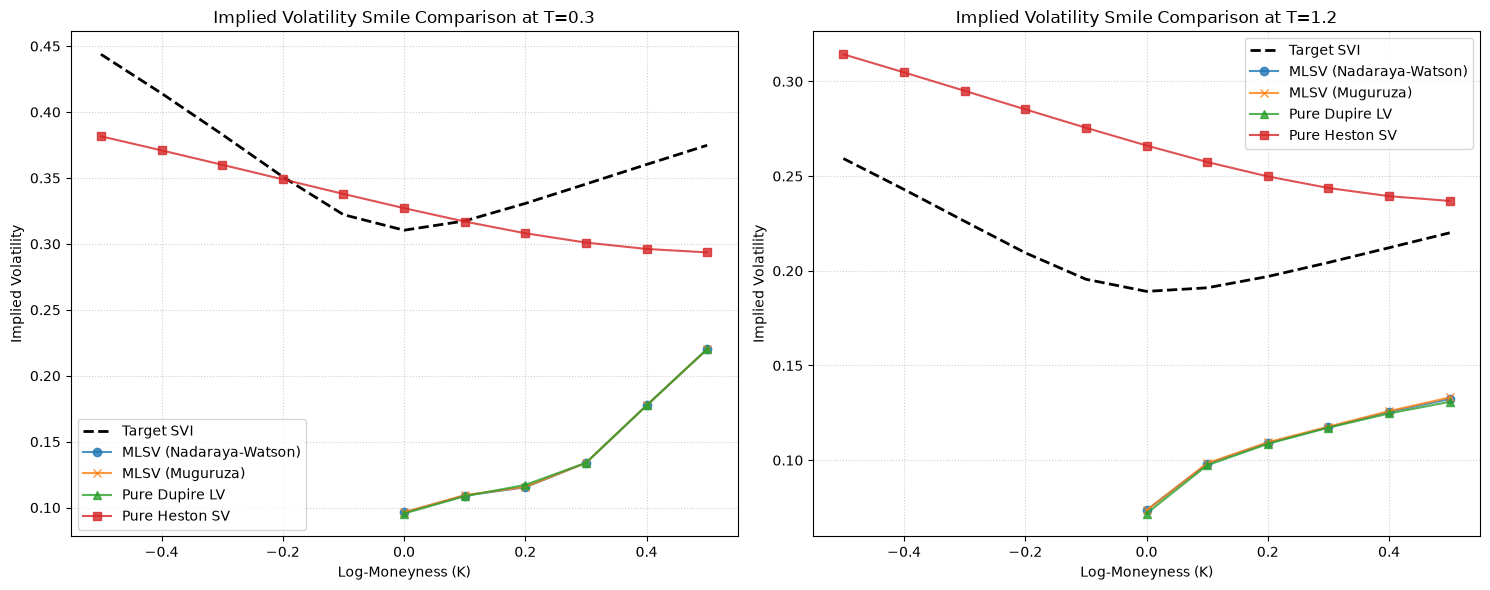

In [8]:
maturities_to_plot = [0.3, 1.2]
fig, axes = plt.subplots(1, len(maturities_to_plot), figsize=(15, 6))

for idx, T in enumerate(maturities_to_plot):
    t_idx = np.argmin(np.abs(T_GRID - T))
    ax = axes[idx]
    
    ax.plot(K_GRID, target_ivs[t_idx], 'k--', label='Target SVI', linewidth=2.0)
    ax.plot(K_GRID, results['MLSV_NW']['ivs'][t_idx], 'o-', label='MLSV (Nadaraya-Watson)', alpha=0.8)
    ax.plot(K_GRID, results['MLSV_Mug']['ivs'][t_idx], 'x-', label='MLSV (Muguruza)', alpha=0.8)
    ax.plot(K_GRID, results['Dupire_LV']['ivs'][t_idx], '^-', label='Pure Dupire LV', alpha=0.8)
    ax.plot(K_GRID, results['Heston']['ivs'][t_idx], 's-', label='Pure Heston SV', alpha=0.8)
    
    ax.set_title(f'Implied Volatility Smile Comparison at T={T_GRID[t_idx]}')
    ax.set_xlabel('Log-Moneyness (K)')
    ax.set_ylabel('Implied Volatility')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()